Simulação 

Detector:<br>
-Pixels: 1024x1024 <br>
-Pixel Size: 0.003 mm <br>
-Size: 307.2 x 307.2 mm<br>

TC:<br>
-DSD = 1150mm <br>
-DSO = 1000 mm <br>
-FOV = 16x112 mm ou 96x112 mm<br> 

Object: <br>
-Phantoma forbild do crânio 

In [1]:
# Importar bibliotecas
import matplotlib.pyplot as plt
import matplotlib.font_manager as font_manager
from matplotlib.widgets import Slider
import numpy as np
import tigre
import tigre.algorithms as algs

In [2]:
import numpy as np

projs = np.load(
    "/mnt/d/Iniciacao_cientifica/head_phantom/imagens_raw2/sinoAula2.npz"
)

projs = projs["sino"]
#projs = projs.transpose(2, 0, 1)

#projs = projs[::-1]

In [3]:
print(projs.shape)

(719, 1024, 1024)


In [ ]:
%run ./utils_completo.ipynb

#alterei

/home/samuel/miniconda3/envs/tomografia-tigre/lib/python3.11/site-packages/nbformat/__init__.py:96: MissingIDFieldWarning: Cell is missing an id field, this will become a hard error in future nbformat versions. You may want to use `normalize()` on your notebooks before validations (available since nbformat 5.1.4). Previous versions of nbformat are fixing this issue transparently, and will stop doing so in the future.
  validate(nb)


In [5]:
printImgData(projs, 'Projeções')

Projeções:: Shape:(719, 1024, 1024), Min:5.5121e-03, Max:1.0049e+00, Mean:4.4966e-01, Type:float32


In [6]:
print(np.count_nonzero(projs==0))

0


In [42]:
#projs = projs.astype(np.float32)+0.01

In [43]:
#projs = np.transpose(projs, (2, 1, 0))

In [44]:
#printImgData(projs, 'Projeções')

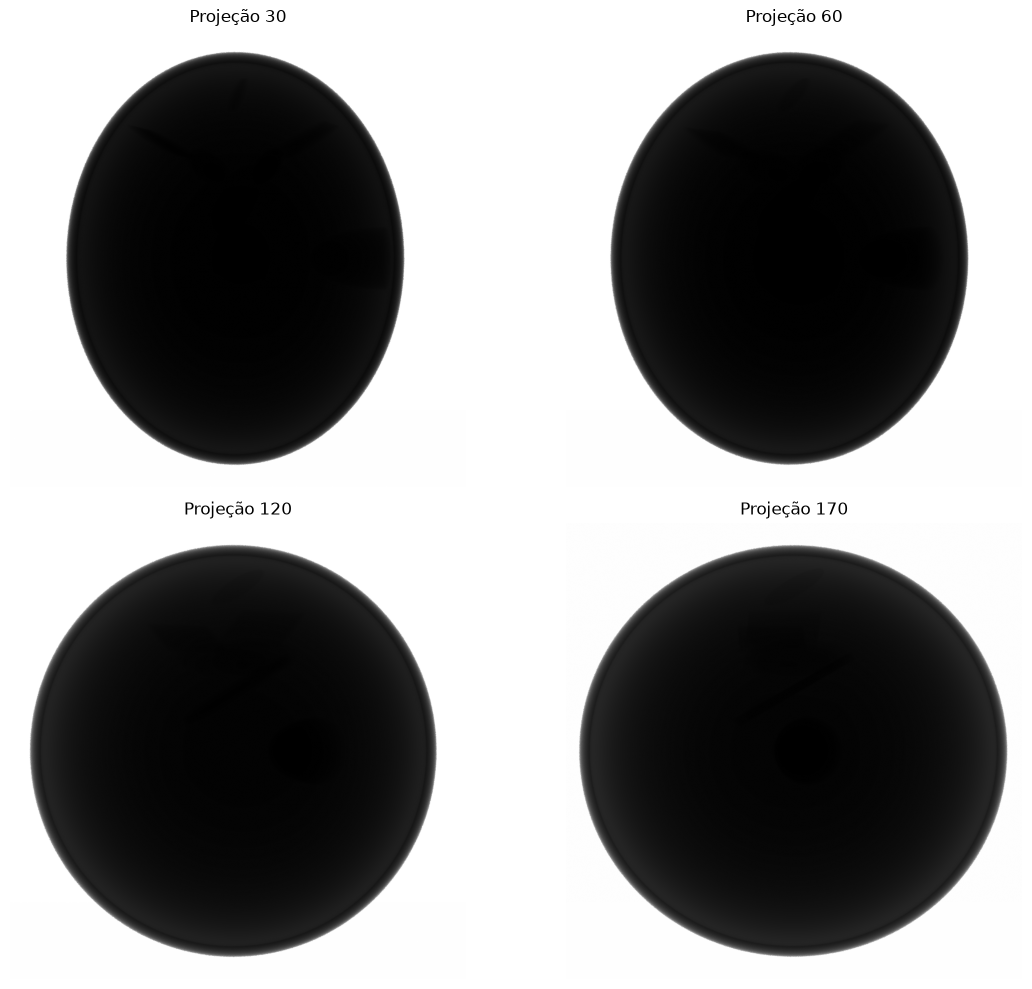

In [7]:
plotFourProjs(projs, _prjs = [30, 60, 120, 170])#, _minv=0, _maxv=0.15)


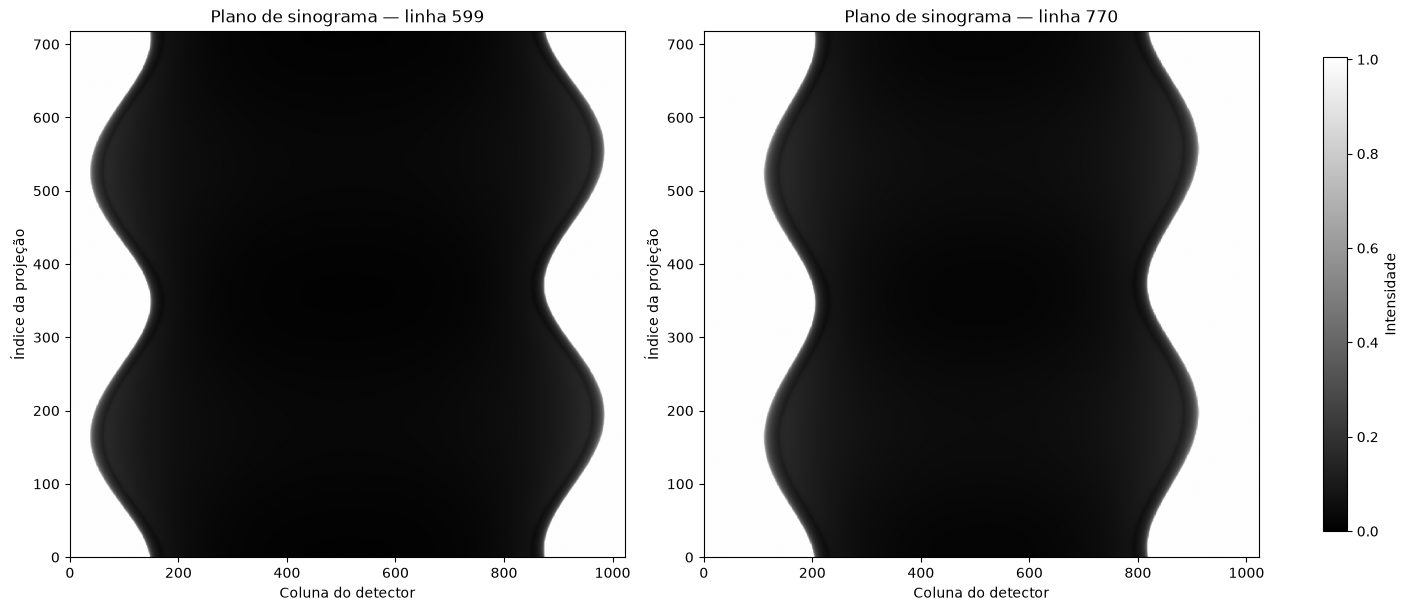

In [8]:
plotTwoSinoPlanes(projs, _lines = [599, 770], _minv=0, _maxv=projs.max()*1.0)

(array([9.94650000e+04, 4.37069000e+05, 4.93356800e+06, 1.05089180e+07,
        1.19347330e+07, 1.18725880e+07, 1.18686400e+07, 1.19967580e+07,
        1.20109710e+07, 1.21394250e+07, 1.25705250e+07, 1.36379470e+07,
        1.35320980e+07, 1.28899990e+07, 1.20592800e+07, 1.10322990e+07,
        1.02432810e+07, 9.59585300e+06, 9.01906900e+06, 8.49559500e+06,
        8.08260800e+06, 7.73075800e+06, 7.36711600e+06, 7.06254300e+06,
        6.78148300e+06, 6.54585400e+06, 6.31560600e+06, 6.11834300e+06,
        5.95223500e+06, 5.82528500e+06, 5.73519700e+06, 5.66032300e+06,
        5.65544500e+06, 5.55520300e+06, 5.38231900e+06, 5.22333400e+06,
        5.05813600e+06, 4.89223600e+06, 4.74275700e+06, 4.60128300e+06,
        4.46508400e+06, 4.34253300e+06, 4.21710000e+06, 4.00224100e+06,
        3.78849100e+06, 3.61931400e+06, 3.47640500e+06, 3.35397400e+06,
        3.24061900e+06, 3.14056000e+06, 3.03884100e+06, 2.95366900e+06,
        2.87792700e+06, 2.80037900e+06, 2.73555500e+06, 2.678548

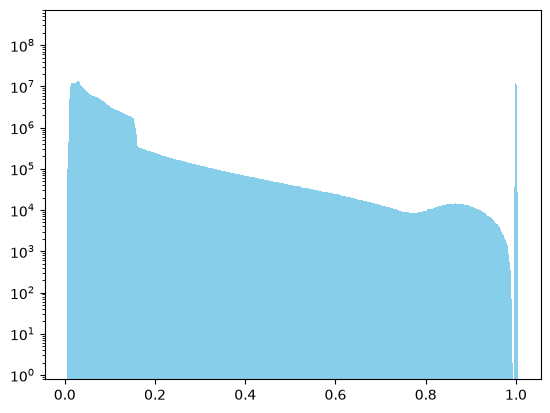

In [ ]:
#Construir o histograma
fig = plt.figure()
ax = plt.axes()
ax.hist(projs[:,:,:].flatten(), bins=512, color='skyblue', log=True)

(0.7, 1.3)

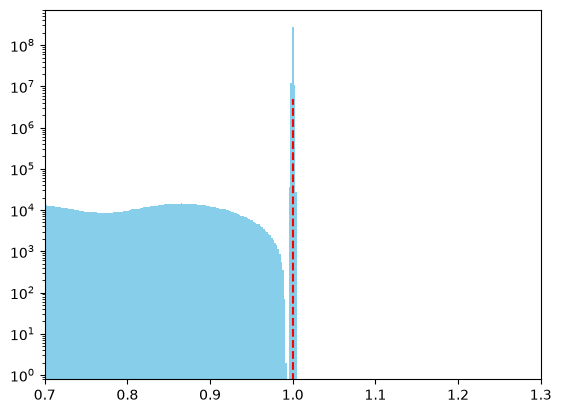

In [10]:
#Pico do fundo do histograma
fig = plt.figure()
ax = plt.axes()
ax.hist(projs[:,:,:].flatten(), bins=512, color='skyblue', log=True)
ax.plot([1.0, 1.0], [0, 5e6], 'r--')
ax.set_xlim(0.7, 1.3)

In [10]:
projs_ln = -np.log(projs/1.0)

In [11]:
count = (projs_ln < 0).sum()
total = projs_ln.size
print(f'Projeções com valores negativos: {count} de {total} ({count/total:.2%})')

Projeções com valores negativos: 45299903 de 753926144 (6.01%)


In [12]:
#Elimina os valores negativos
projs_ln [projs_ln < 0] = 0

In [13]:
#%% Definir a geometria 
geo = tigre.geometry_default(high_resolution=True)

In [14]:
# Distances
geo.DSD = 1150  # Distance Source Detector      (mm)
geo.DSO = 1000  # Distance Source Origin        (mm)
# Detector parameters
geo.nDetector = np.array([1024, 1024])  # number of pixels              (px)
geo.dDetector = np.array([0.3, 0.3])  # size of each pixel            (mm)
geo.sDetector = geo.nDetector * geo.dDetector  # total size of the detector    (mm)
# Image parameters
geo.nVoxel = np.array([384, 400, 400])  # number of voxels              (vx)
geo.sVoxel = np.array([240, 250, 250])  # total size of the image       (mm)
geo.dVoxel = geo.sVoxel / geo.nVoxel  # size of each voxel            (mm)

geo.accuracy = 0.5

In [15]:
#Angulos em radianos
#angles = np.linspace(0, 2*np.pi-np.pi/180, 360)
angles = np.linspace(0, 360, 719,

    endpoint=False,
    dtype=np.float32
)

##Visualizar os ângulos em graus
#angles = np.linspace(0, 360-360/360, 360)
#print(angles)
#angles = angles * np.pi / 180

print(angles)

angles = np.deg2rad(angles)


print(angles)

[  0.          0.5006954   1.0013908   1.5020863   2.0027816   2.503477
   3.0041726   3.5048678   4.0055633   4.5062585   5.006954    5.5076494
   6.008345    6.5090404   7.0097356   7.5104313   8.0111265   8.511822
   9.012517    9.513213   10.013908   10.514604   11.015299   11.515994
  12.01669    12.5173855  13.018081   13.518776   14.019471   14.520167
  15.020863   15.521558   16.022253   16.52295    17.023643   17.52434
  18.025034   18.52573    19.026426   19.52712    20.027817   20.528511
  21.029207   21.529903   22.030598   22.531294   23.031988   23.532684
  24.03338    24.534075   25.034771   25.535465   26.036161   26.536858
  27.037552   27.538248   28.038942   28.539639   29.040335   29.541029
  30.041725   30.54242    31.043116   31.543812   32.044506   32.5452
  33.0459     33.546593   34.047287   34.547985   35.04868    35.549374
  36.050068   36.550766   37.05146    37.552155   38.052853   38.553547
  39.05424    39.55494    40.055634   40.556328   41.057022   41.5

In [16]:
print(geo)
print(geo.accuracy)
print(angles.shape)
print(angles)

TIGRE parameters
-----
Geometry parameters
Distance from source to detector (DSD) = 1150 mm
Distance from source to origin (DSO)= 1000 mm
-----
Detector parameters
Number of pixels (nDetector) = [1024 1024]
Size of each pixel (dDetector) = [0.3 0.3] mm
Total size of the detector (sDetector) = [307.2 307.2] mm
-----
Image parameters
Number of voxels (nVoxel) = [384 400 400]
Total size of the image (sVoxel) = [240 250 250] mm
Size of each voxel (dVoxel) = [0.625 0.625 0.625] mm
-----
Offset correction parameters
Offset of image from origin (offOrigin) = [0 0 0] mm
Offset of detector (offDetector) = [0 0] mm
-----
Auxillary parameters
Samples per pixel of forward projection (accuracy) = 0.5
0.5
(719,)
[0.         0.00873878 0.01747757 0.02621635 0.03495513 0.04369392
 0.0524327  0.06117148 0.06991027 0.07864904 0.08738784 0.09612662
 0.1048654  0.11360419 0.12234297 0.13108176 0.13982053 0.14855932
 0.15729809 0.16603689 0.17477567 0.18351445 0.19225323 0.20099202
 0.2097308  0.21846959 0

In [17]:


imgFDK = algs.fdk(
    projs_ln,
    geo,
    angles,
    filter="hann"
)

print("Resultado:", imgFDK.shape)

Resultado: (384, 400, 400)


In [ ]:
# Definindo ROI`s
#imgFDK[z, y, x]


#roi_agua = imgFDK [0:10, 650:750, 480:550]
#roi_ar = imgFDK [0:10, 852:922,60:130]

roi_agua = imgFDK [250:260, 185:210, 180:230]
roi_ar = imgFDK [94:104, 40:80, 20:80]
roi_osso = imgFDK [378:388, 190:215, 180:220]



mu_ar = np.mean(roi_ar)
mu_agua = np.mean(roi_agua)
mu_osso = np.mean(roi_osso)

mu_agua_std = np.std(roi_agua)
mu_ar_std = np.std(roi_ar)
mu_osso_std = np.std(roi_osso)

print("μ água =", mu_agua)
print("μ ar =", mu_ar)
print("μ osso =", mu_osso)

print("Desvio padrão agua=", mu_agua_std)
print("Desvio padrão ar=", mu_ar_std)
print("Desvio padrão osso=", mu_osso_std)


μ água = 0.017079731
μ ar = 0.0004907406
μ osso = 0.03397865
Desvio padrão agua= 6.0777187e-05
Desvio padrão ar= 0.0008847283
Desvio padrão osso= 0.0045658867


In [67]:
#Convertendo para escala HU 

imgHU = 1000 * ((imgFDK - mu_agua) / (mu_agua - mu_ar))


#Verficando calibração dos materiais

roi_agua_HU = 1000 * ((roi_agua - mu_agua) / (mu_agua - mu_ar))
roi_ar_HU= 1000 * ((roi_ar   - mu_agua) / (mu_agua - mu_ar))
roi_osso_HU= 1000 * ((roi_osso - mu_agua) / (mu_agua - mu_ar))

HU_agua = np.mean(roi_agua_HU)
HU_ar   = np.mean(roi_ar_HU)
HU_osso = np.mean(roi_osso_HU)

print("HU água =", HU_agua)
print("HU ar   =", HU_ar)
print("HU osso =", HU_osso)

HU água = 8.022461e-06
HU ar   = -1000.0
HU osso = 1018.68256


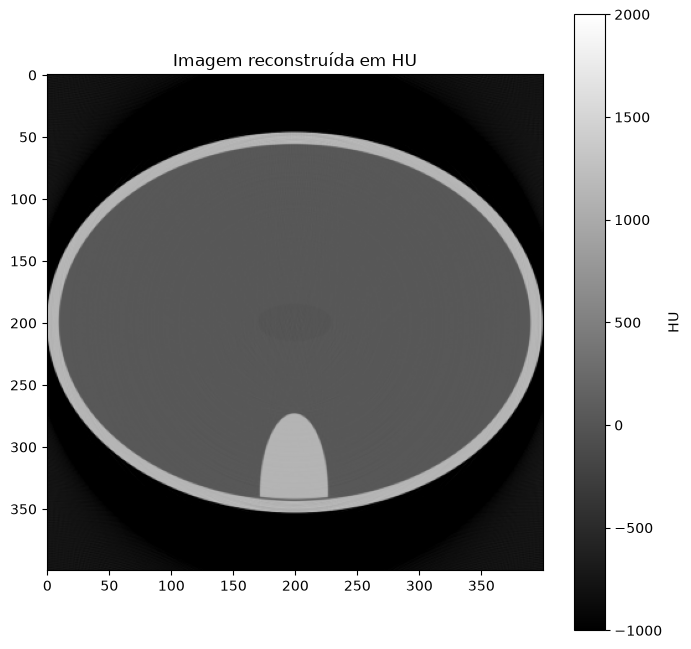

In [65]:
# ============================================================
# VISUALIZAÇÃO DA IMAGEM EM HU
# ============================================================

slice_z = imgHU.shape[2] // 2

plt.figure(figsize=(8, 8))

plt.imshow(
    imgHU[slice_z],
    cmap="gray",
    vmin=-1000,
    vmax=2000
)

plt.colorbar(label="HU")
plt.title("Imagem reconstruída em HU")

plt.show()

In [ ]:
#niter = 10
#imgOSSART = algs.ossart(projs_ln.astype('float32'), geo, angles, niter)

In [26]:
print('FDK:', imgFDK.shape, imgFDK.min(), imgFDK.max(), imgFDK.mean())
#print('OSSSART:', imgOSSART.shape, imgOSSART.min(), imgOSSART.max(), imgOSSART.mean())

FDK: (384, 400, 400) -0.009420291 0.043773487 0.008482084


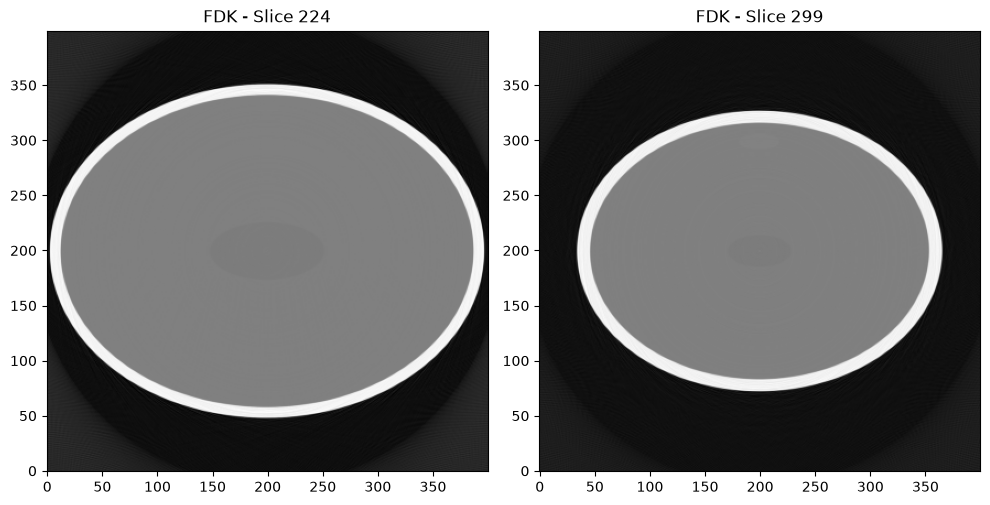

In [27]:
import matplotlib.pyplot as plt

original_size = 1024
new_size = imgFDK.shape[0]

slice1 = round(
    599 * (new_size - 1) / (original_size - 1)
)

slice2 = round(
    799 * (new_size - 1) / (original_size - 1)
)

fig, ax = plt.subplot_mosaic(
    [[0, 1]],
    figsize=(10, 6)
)

ax[0].imshow(
    imgFDK[slice1],
    cmap="gray"
)
ax[0].set_title(
    f"FDK - Slice {slice1}",
    fontsize=12
)
ax[0].invert_yaxis()

ax[1].imshow(
    imgFDK[slice2],
    cmap="gray"
)
ax[1].set_title(
    f"FDK - Slice {slice2}",
    fontsize=12
)
ax[1].invert_yaxis()

plt.tight_layout()
plt.show()

In [1]:
fig, ax = plt.subplot_mosaic(
    [[0, 1]],
    figsize=(12, 5)
)

_slice = 300

ax[0].imshow(
    imgFDK[:, _slice//2, :],
    cmap="gray",
    vmin=np.percentile(imgFDK, 1),
    vmax=np.percentile(imgFDK, 99.5)
)
ax[0].set_title(f"Slice {_slice//2}", fontsize=12)
ax[0].invert_yaxis()

ax[1].imshow(
    imgFDK[:, _slice, :],
    cmap="gray",
    vmin=np.percentile(imgFDK, 1),
    vmax=np.percentile(imgFDK, 99.5)
)
ax[1].set_title(f"Slice {_slice}", fontsize=12)

ax[1].hlines(
    [224, 299],
    *ax[1].get_xlim(),
    color="red",
    linestyle="--"
)

ax[1].invert_yaxis()

NameError: name 'plt' is not defined

In [29]:
np.savez(
    "/mnt/d/Iniciacao_cientifica/head_phantom/volume2.npz",
    volume=imgFDK
)

In [21]:
np.savez(
    "/mnt/d/Iniciacao_cientifica/head_phantom/volume2_hu.npz",
    volume=imgHU
)